In [9]:
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import linopy.constants

In [10]:
import os
import sys

# Set path to the directory containing base.py
module_path = os.path.abspath(".")

if module_path not in sys.path:
    sys.path.append(module_path)

import base  # now you can use base.build_network()

from visualization import *

In [ ]:
weather_years = range(2010,2016)
results_capacities = {}
networks_interannual = []

for year in weather_years:
    network = base.build_network(solve=True, year=year)
    results_capacities[year] = network.generators.p_nom_opt
    networks_interannual.append(network)



c:\Users\Bruger\Git-projects\46770_IEG\base.py:26: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  snapshots = pd.date_range(f"{year}-01-01", f"{year}-12-31 23:00", freq="H")
c:\Users\Bruger\Git-projects\46770_IEG\base.py:94: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily["Inflow [MW]"] = df_daily["Inflow [GWh]"] * 1000 / 24  # MW average per hour
c:\Users\Bruger\Git-projects\46770_IEG\base.py:96: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  inflow_ror_hourly = df_daily["Inflow [MW]"].resample("H").interpolate("linear")
Index(['DEU_elec'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:


--- Interannual Variability Results ---
             Average Capacity [GW]  Std Dev [GW]
Generator                                       
coal                      0.000000      0.000000
lignite                  30.000000      0.000000
biomass CHP               5.000000      0.000000
OCGT                     41.638194      0.328649
ror                       0.000000      0.000000
onwind                    2.157979      3.327979
offwind                   2.123769      1.807688
solar                     9.411777      7.228972

Optimal Capacities (GW) per Weather Year:
Weather Year    2010    2011    2012    2013    2014    2015
Generator                                                   
coal          -0.000  -0.000  -0.000  -0.000  -0.000  -0.000
lignite       30.000  30.000  30.000  30.000  30.000  30.000
biomass CHP    5.000   5.000   5.000   5.000   5.000   5.000
OCGT          41.521  41.362  42.231  41.638  41.736  41.340
ror           -0.000  -0.000  -0.000  -0.000  -0.000  -0.000


--- Interannual Variability Results ---
             Average Capacity [GW]  Std Dev [GW]
Generator                                       
coal                      0.000000      0.000000
lignite                  30.000000      0.000000
biomass CHP               5.000000      0.000000
OCGT                     41.638194      0.328649
ror                       0.000000      0.000000
onwind                    2.157979      3.327979
offwind                   2.123769      1.807688
solar                     9.411777      7.228972

Optimal Capacities (GW) per Weather Year:
Weather Year    2010    2011    2012    2013    2014    2015
Generator                                                   
coal          -0.000  -0.000  -0.000  -0.000  -0.000  -0.000
lignite       30.000  30.000  30.000  30.000  30.000  30.000
biomass CHP    5.000   5.000   5.000   5.000   5.000   5.000
OCGT          41.521  41.362  42.231  41.638  41.736  41.340
ror           -0.000  -0.000  -0.000  -0.000  -0.000  -0.000

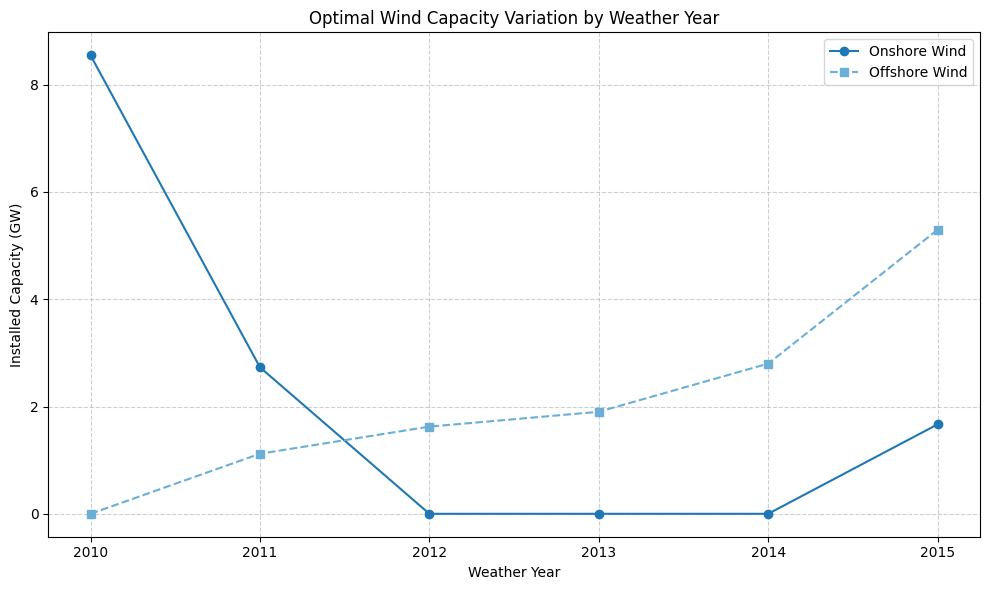

In [16]:
if results_capacities: 
        df_capacities_yearly = pd.DataFrame(results_capacities).div(1e3) # Convert MW to GW
        df_capacities_yearly.index.name = "Generator"
        df_capacities_yearly.columns.name = "Weather Year"

        avg_caps_gw = df_capacities_yearly.mean(axis=1)
        std_caps_gw = df_capacities_yearly.std(axis=1)

        # Combine average and std dev for plotting/reporting
        df_stats = pd.DataFrame({"Average Capacity [GW]": avg_caps_gw, "Std Dev [GW]": std_caps_gw})

        print("\n--- Interannual Variability Results ---")
        print(df_stats)
        # Also print the yearly results for reference
        print("\nOptimal Capacities (GW) per Weather Year:")
        print(df_capacities_yearly.round(3)) # Round for better readability
else:
        print("\nNo simulation results to display.")

plot_interannual_wind_capacity(df_capacities_yearly)

    # Select data for onshore and offshore wind
    # Transpose the DataFrame so years are on the x-axis (index)
    